# **ASSIGNMENT 1**

**Import Libraries**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

**Load and Clean Data**

In [ ]:
from google.colab import files

# This will prompt you to choose a file from your computer
uploaded = files.upload()

# Load the dataset
df = pd.read_csv('emails.csv')

# Remove duplicates (common in email datasets)
df.drop_duplicates(inplace=True)

# Display the first 5 rows to make sure it loaded correctly
print(f"Total emails: {len(df)}")
df.head()

Saving emails.csv to emails.csv
Total emails: 5695


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


**Preprocessing and Splitting**

In [ ]:
# X = Email text, y = Label (1 for Spam, 0 for Ham)
X = df['text']
y = df['spam']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text into numbers (Word Counts)
# We use stop_words='english' to ignore common words like 'the', 'is', 'and'
vectorizer = CountVectorizer(stop_words='english')
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

print("Text has been converted to a numerical matrix.")

Text has been converted to a numerical matrix.


**Train the Naive Bayes Model**

In [ ]:
# Initialize and train the Multinomial Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train_counts, y_train)

print("Model training complete!")

Model training complete!


**Evaluation**

In [ ]:
# Make predictions
predictions = model.predict(X_test_counts)

# Print accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:\n")
print(classification_report(y_test, predictions))

Accuracy: 99.21%

Detailed Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       843
           1       0.99      0.98      0.98       296

    accuracy                           0.99      1139
   macro avg       0.99      0.99      0.99      1139
weighted avg       0.99      0.99      0.99      1139



**Test Interactively**

In [ ]:
def predict_spam(text):
    # Convert the input text into the numerical format the model expects
    data = vectorizer.transform([text])

    # Make the prediction
    prediction = model.predict(data)

    # Return the formatted result
    return "🚨 SPAM" if prediction[0] == 1 else "✅ HAM (Safe)"

# Prompt the user for input
user_email = input("Paste the email text you want to check: ")

# Display the result
print(f"\nPrediction: {predict_spam(user_email)}")

Paste the email text you want to check: HELLO I M MONEY

Prediction: 🚨 SPAM


# **ASSIGNMENT 2**

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("dataset_sdn.csv")

print("Dataset Loaded Successfully")

# =========================
# CLEAN COLUMN NAMES
# =========================

df.columns = df.columns.str.strip()

print(df.columns)

# =========================
# TAKE SAMPLE
# =========================

df = df.sample(n=10000, random_state=42)

# =========================
# DROP NON-USEFUL COLUMNS
# =========================

drop_cols = ['src', 'dst']

for col in drop_cols:
    if col in df.columns:
        df = df.drop(col, axis=1)

# =========================
# ENCODE CATEGORICAL COLUMNS
# =========================

le = LabelEncoder()

categorical_cols = ['switch', 'Protocol']

for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# =========================
# HANDLE MISSING VALUES
# =========================

print("\nMissing Values Before Cleaning:\n")
print(df.isnull().sum())

# Fill numeric NaN values with mean
df = df.fillna(df.mean(numeric_only=True))

# Drop remaining NaN rows
df = df.dropna()

print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())

# =========================
# FEATURES AND TARGET
# =========================

X = df.drop("label", axis=1)
y = df["label"]
# VISUALIZATION 1:
# CLASS DISTRIBUTION
# =========================

plt.figure(figsize=(6,5))

y.value_counts().plot(
    kind='bar',
    color=['green', 'red']
)

plt.title("Attack vs Normal Traffic")
plt.xlabel("Class")
plt.ylabel("Count")

plt.grid(axis='y')

plt.show()

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# MODEL TRAINING
# =========================

model = GaussianNB()

model.fit(X_train, y_train)

# =========================
# PREDICTION
# =========================

y_pred = model.predict(X_test)

# =========================
# ACCURACY
# =========================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

# =========================
# CLASSIFICATION REPORT
# =========================

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# =========================
# VISUALIZATION 2:
# CONFUSION MATRIX
# =========================

plt.figure(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")

plt.show()

# =========================
# VISUALIZATION 3:
# FEATURE HISTOGRAMS
# =========================

numeric_cols = X.select_dtypes(include=np.number).columns

for col in numeric_cols[:4]:

    plt.figure(figsize=(6,4))

    plt.hist(df[col], bins=30)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.grid()

    plt.show()

# =========================
# VISUALIZATION 4:
# ACTUAL VS PREDICTED
# =========================

comparison = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Predicted': y_pred[:20]
})

comparison.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Actual vs Predicted")
plt.xlabel("Samples")
plt.ylabel("Class")

plt.grid()

plt.show()

print("\nModel Completed Successfully")

# **ASSIGNMENT 3**

In [ ]:
# ----------------------------------------
# Import Libraries
# ----------------------------------------

import pandas as pd

from sklearn.model_selection import train_test_split

# ----------------------------------------
# Load Dataset
# ----------------------------------------

df = pd.read_csv("emails.csv")

# Display first 5 rows
print(df.head())

# ----------------------------------------
# Features and Target
# ----------------------------------------

# Input feature
X = df["text"]

# Output label
y = df["spam"]

# ----------------------------------------
# Split Dataset
# ----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

# ----------------------------------------
# Display Shapes
# ----------------------------------------

print("\nTraining Data Size :", X_train.shape)

print("Testing Data Size :", X_test.shape)

print("Training Labels Size :", y_train.shape)

print("Testing Labels Size :", y_test.shape)

                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1

Training Data Size : (4582,)
Testing Data Size : (1146,)
Training Labels Size : (4582,)
Testing Labels Size : (1146,)


# **# ASSIGNMENT 4**

In [ ]:
# ----------------------------------------
# Import Libraries
# ----------------------------------------

import pandas as pd
import re

# ----------------------------------------
# Load Dataset
# ----------------------------------------

df = pd.read_csv("emails.csv")

print(df.head())

# ----------------------------------------
# Remove Missing Values
# ----------------------------------------

df = df.dropna()

# ----------------------------------------
# Text Cleaning Function
# ----------------------------------------

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Remove extra spaces
    text = text.strip()

    return text

# Apply cleaning
df["clean_text"] = df["text"].apply(
    clean_text
)

# ----------------------------------------
# Feature Engineering
# ----------------------------------------

# Count total words
df["word_count"] = df["clean_text"].apply(

    lambda x: len(x.split())

)

# Count characters
df["char_count"] = df["clean_text"].apply(

    len

)

# Count uppercase words
df["uppercase_words"] = df["text"].apply(

    lambda x: sum(
        word.isupper()
        for word in str(x).split()
    )

)

# Count exclamation marks
df["exclamation_count"] = df["text"].apply(

    lambda x: str(x).count("!")

)

# ----------------------------------------
# Display Engineered Features
# ----------------------------------------

print(

    df[[
        "text",
        "clean_text",
        "word_count",
        "char_count",
        "uppercase_words",
        "exclamation_count"
    ]].head()

)

df.head()

                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1
                                                text  \
0  Subject: naturally irresistible your corporate...   
1  Subject: the stock trading gunslinger  fanny i...   
2  Subject: unbelievable new homes made easy  im ...   
3  Subject: 4 color printing special  request add...   
4  Subject: do not have money , get software cds ...   

                                          clean_text  word_count  char_count  \
0  subject naturally irresistible your corporate ...         292        1449   
1  subject the stock trading gunslinger  fanny is...          89         596   
2  subject unbelievable new homes made easy  im w...          75     

,text,spam,clean_text,word_count,char_count,uppercase_words,exclamation_count
0,Subject: naturally irresistible your corporate...,1,subject naturally irresistible your corporate ...,292,1449,0,0
1,Subject: the stock trading gunslinger fanny i...,1,subject the stock trading gunslinger fanny is...,89,596,0,0
2,Subject: unbelievable new homes made easy im ...,1,subject unbelievable new homes made easy im w...,75,430,0,0
3,Subject: 4 color printing special request add...,1,subject color printing special request addit...,65,443,0,2
4,"Subject: do not have money , get software cds ...",1,subject do not have money get software cds fr...,40,221,0,1


**DMW APRIORI**

Transaction Dataset:

   Bread  Butter   Milk
0   True    True   True
1   True    True  False
2   True   False   True
3  False    True   True
4   True    True  False
5   True    True   True
6   True   False   True
7  False    True  False
8  False    True   True
9   True    True   True

Frequent Itemsets:

   support               itemsets
0      0.7                (Bread)
1      0.8               (Butter)
2      0.7                 (Milk)
3      0.5        (Bread, Butter)
4      0.5          (Bread, Milk)
5      0.5         (Milk, Butter)
6      0.3  (Bread, Milk, Butter)

Association Rules:

       antecedents consequents  support  confidence      lift
0          (Bread)    (Butter)      0.5    0.714286  0.892857
1         (Butter)     (Bread)      0.5    0.625000  0.892857
2          (Bread)      (Milk)      0.5    0.714286  1.020408
3           (Milk)     (Bread)      0.5    0.714286  1.020408
4           (Milk)    (Butter)      0.5    0.714286  0.892857
5         (Butter)      (Mil

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


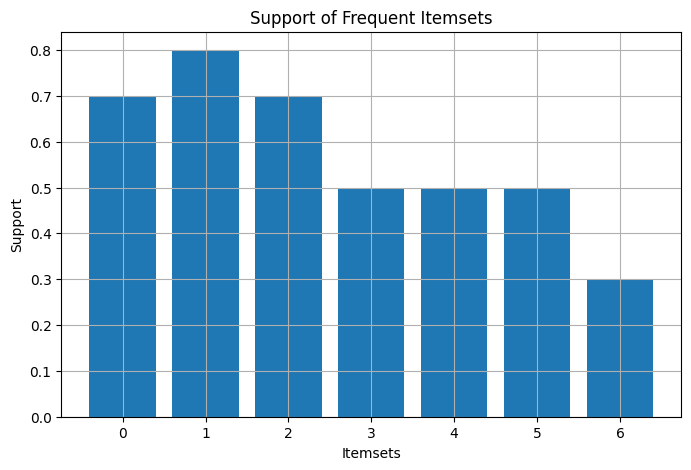

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

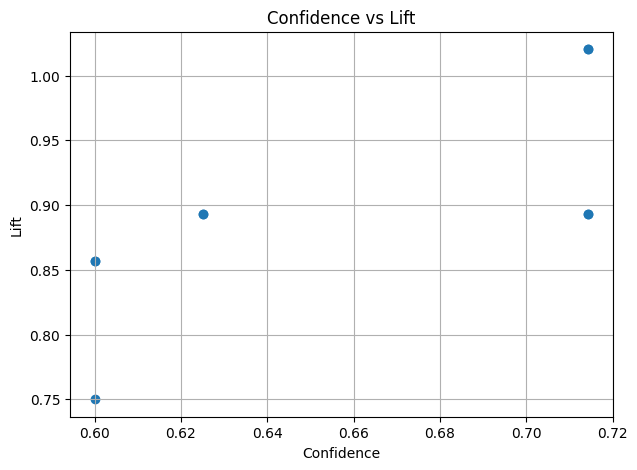


Apriori Algorithm Executed Successfully


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [1]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# =========================
# SAMPLE TRANSACTION DATA
# =========================

dataset = [
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Butter'],
    ['Milk', 'Bread'],
    ['Milk', 'Butter'],
    ['Bread', 'Butter'],
    ['Milk', 'Bread', 'Butter'],
    ['Milk', 'Bread'],
    ['Butter'],
    ['Milk', 'Butter'],
    ['Milk', 'Bread', 'Butter']
]

# =========================
# CONVERT DATA INTO MATRIX
# =========================

te = TransactionEncoder()

te_array = te.fit(dataset).transform(dataset)

df = pd.DataFrame(te_array, columns=te.columns_)

print("Transaction Dataset:\n")
print(df)

# =========================
# APPLY APRIORI ALGORITHM
# =========================

frequent_itemsets = apriori(
    df,
    min_support=0.3,
    use_colnames=True
)

print("\nFrequent Itemsets:\n")
print(frequent_itemsets)

# =========================
# GENERATE ASSOCIATION RULES
# =========================

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

print("\nAssociation Rules:\n")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# =========================
# VISUALIZATION 1:
# SUPPORT OF ITEMSETS
# =========================

plt.figure(figsize=(8,5))

plt.bar(
    range(len(frequent_itemsets)),
    frequent_itemsets['support']
)

plt.title("Support of Frequent Itemsets")
plt.xlabel("Itemsets")
plt.ylabel("Support")

plt.grid()

plt.show()

# =========================
# VISUALIZATION 2:
# CONFIDENCE VS LIFT
# =========================

plt.figure(figsize=(7,5))

plt.scatter(
    rules['confidence'],
    rules['lift']
)

plt.title("Confidence vs Lift")
plt.xlabel("Confidence")
plt.ylabel("Lift")

plt.grid()

plt.show()

print("\nApriori Algorithm Executed Successfully")